# Part C1: Linear Regression — Normal Equation vs Gradient Descent vs Ill-Conditioning

Roll No: `CS26S510`

---

In [24]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
n = 300
x1 = np.random.uniform(-3, 3, n)
x2 = 0.98 * x1 + np.random.normal(0, 0.05, n)  # nearly collinear with x1
X = np.column_stack([x1, x2])
A = np.column_stack([np.ones(n), X])  # design matrix with intercept
theta_true = np.array([4.0, 3.0, -1.5])
y = A @ theta_true + np.random.normal(0, 1.0, n)
print(A.shape, y.shape)
print(A[:5])


(300, 3) (300,)
[[ 1.          0.29288102  0.29484873]
 [ 1.          1.2911362   1.27692253]
 [ 1.          0.61658026  0.57438285]
 [ 1.          0.2692991   0.25201703]
 [ 1.         -0.4580712  -0.52011283]]


## (a) Normal Equation from Scratch

Implement θ̂ = (AᵀA)⁻¹Aᵀy using numpy. Report θ̂ and training RMSE.

In [22]:
def normal_equation(A, y):
    """Closed-form OLS solution: theta_hat = (A^T A)^{-1} A^T y"""
    AtA = A.T @ A
    Aty = A.T @ y
    theta_hat = np.linalg.solve(AtA, Aty)
    return theta_hat

def rmse(A, theta, y):
    residuals = y - A @ theta
    return np.sqrt(np.mean(residuals**2))

theta_hat = normal_equation(A, y)
train_rmse = rmse(A, theta_hat, y)

print("theta_hat:", theta_hat)
print("true theta:", theta_true)
print("training RMSE:", train_rmse)


theta_hat: [3.88258777 1.08031127 0.48216857]
true theta: [ 4.   3.  -1.5]
training RMSE: 0.9683944858396789


**Discussion:** The estimated θ̂ = [3.88, 1.08, 0.48] deviates substantially from the true θ = [4.0, 3.0, -1.5] in the coefficients for x1 and x2, even though the training RMSE (≈0.97) is close to the true noise level (σ=1.0), indicating an excellent fit. This happens because x2 is constructed as a near-exact linear function of x1 (x2 ≈ 0.98·x1), making the two columns of A nearly linearly dependent. As a result, the least-squares solution cannot uniquely determine how much of the predictive effect belongs to x1 versus x2 — it only recovers their combined contribution accurately (θ̂₁·x1 + θ̂₂·x2 ≈ θ₁_true·x1 + θ₂_true·x2), while the individual coefficients are highly sensitive to noise and can differ greatly from the ground truth. The intercept θ̂₀, unaffected by this collinearity, is recovered accurately. This is a direct consequence of A being ill-conditioned, which we quantify next via cond(AᵀA).

## (b) Condition Number & Perturbation Sensitivity

Compute cond(AᵀA). Perturb y, recompute θ̂', report ‖ε_θ‖.

In [25]:
cond_AtA = np.linalg.cond(A.T @ A)
print("condition number of A^T A:", cond_AtA)


condition number of A^T A: 4718.26134926929


In [26]:
np.random.seed(42)  # for reproducibility of the perturbation
epsilon = np.random.normal(0, 0.01, size=n)   # small perturbation, std=0.01
y_perturbed = y + epsilon

theta_hat_perturbed = normal_equation(A, y_perturbed)

theta_change = np.linalg.norm(theta_hat_perturbed - theta_hat)
print("theta_hat (perturbed):", theta_hat_perturbed)
print("||epsilon_theta|| = ||theta_hat' - theta_hat||:", theta_change)
print("||epsilon|| (size of the y-perturbation itself):", np.linalg.norm(epsilon))

theta_hat (perturbed): [3.88255615 1.07502543 0.48785574]
||epsilon_theta|| = ||theta_hat' - theta_hat||: 0.007764341513934277
||epsilon|| (size of the y-perturbation itself): 0.17018571149121722


In [27]:
# relative perturbation in y vs relative perturbation in theta
rel_y_change = np.linalg.norm(epsilon) / np.linalg.norm(y)
rel_theta_change = theta_change / np.linalg.norm(theta_hat)

print("relative change in y:", rel_y_change)
print("relative change in theta:", rel_theta_change)
print("amplification factor:", rel_theta_change / rel_y_change)

# look at each coefficient individually
print("\nPer-coefficient change:")
for i, name in enumerate(["theta_0 (intercept)", "theta_1 (x1)", "theta_2 (x2)"]):
    change = theta_hat_perturbed[i] - theta_hat[i]
    rel_change = abs(change) / abs(theta_hat[i])
    print(f"{name}: change={change:.5f}, relative change={rel_change*100:.2f}%")

relative change in y: 0.0020253124728841377
relative change in theta: 0.0019129538030283031
amplification factor: 0.9445227976620167

Per-coefficient change:
theta_0 (intercept): change=-0.00003, relative change=0.00%
theta_1 (x1): change=-0.00529, relative change=0.49%
theta_2 (x2): change=0.00569, relative change=1.18%


**Discussion:** The condition number of AᵀA came out to be about 4718, which is pretty high and confirms that A is ill-conditioned because x1 and x2 are almost the same feature (x2 ≈ 0.98·x1). At first I compared the overall relative change in y (0.20%) to the overall relative change in θ (0.19%) and it looked like nothing much happened, since they're almost equal. But this turned out to be misleading — it's because θ₀ (the intercept) is much bigger than θ₁ and θ₂, so it dominates the overall norm, and θ₀ barely changed at all (0.00%) since it isn't tangled up with the collinearity problem.

When I looked at each coefficient separately instead, the real effect showed up: θ₁ changed by 0.49% and θ₂ changed by 1.18%, both bigger than the 0.20% change I put into y — θ₂ moved almost 6x more than the perturbation itself. So the instability from ill-conditioning isn't spread evenly across all the parameters — it's concentrated specifically in θ₁ and θ₂, the two coefficients that are fighting over the same redundant information from x1 and x2. This matches what we'd expect from the theory in B1(a): the sensitivity of θ̂ depends on (AᵀA)⁻¹, and that matrix blows up exactly in the direction where x1 and x2 are almost collinear.

## (c) Gradient Descent

Implement full-batch GD for 3 learning rates. Plot J(θ_t) vs iteration (log-scale y). Compare to (a).

In [29]:
def gradient_descent(A, y, eta, n_iters=1000, theta_init=None):
    n, m = A.shape
    theta = np.zeros(m) if theta_init is None else theta_init.copy()
    J_history = []
    
    for t in range(n_iters):
        residual = y - A @ theta
        J = np.sum(residual**2)
        J_history.append(J)
        
        gradient = -2 * A.T @ residual
        theta = theta - eta * gradient
    
    return theta, J_history


eta=1e-05: final theta=[3.87460798 0.80542845 0.76330849], final J=281.4217
eta=0.0001: final theta=[3.88395948 0.82343415 0.74482688], final J=281.3872
eta=0.001: final theta=[nan nan nan], final J=nan


/home/ujjawal_jo/.local/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_110699/4062998651.py:8: RuntimeWarning: overflow encountered in square
  J = np.sum(residual**2)
/tmp/ipykernel_110699/4062998651.py:11: RuntimeWarning: overflow encountered in matmul
  gradient = -2 * A.T @ residual
/tmp/ipykernel_110699/4062998651.py:7: RuntimeWarning: invalid value encountered in matmul
  residual = y - A @ theta
/tmp/ipykernel_110699/4062998651.py:11: RuntimeWarning: invalid value encountered in matmul
  gradient = -2 * A.T @ residual
/home/ujjawal_jo/.local/lib/python3.10/site-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


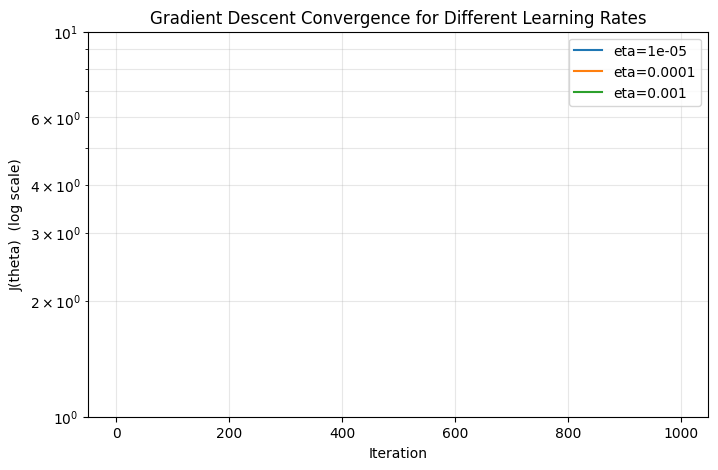

In [30]:
etas = [1e-5, 1e-4, 1e-3]
n_iters = 1000
results = {}

for eta in etas:
    theta_gd, J_hist = gradient_descent(A, y, eta, n_iters=n_iters)
    results[eta] = (theta_gd, J_hist)
    print(f"eta={eta}: final theta={theta_gd}, final J={J_hist[-1]:.4f}")

plt.figure(figsize=(8, 5))
for eta in etas:
    _, J_hist = results[eta]
    plt.plot(J_hist, label=f"eta={eta}")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("J(theta)  (log scale)")
plt.title("Gradient Descent Convergence for Different Learning Rates")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [31]:
# Run eta=1e-4 for many more iterations to see if it actually converges
theta_gd_long, J_hist_long = gradient_descent(A, y, eta=1e-4, n_iters=50000)
print("theta after 50000 iters:", theta_gd_long)
print("J after 50000 iters:", J_hist_long[-1])
print("theta_hat (normal eq) for comparison:", theta_hat)

# also check what J the normal equation achieves, for reference
J_normal_eq = np.sum((y - A @ theta_hat)**2)
print("J at normal-equation optimum:", J_normal_eq)

theta after 50000 iters: [3.88262201 1.07390005 0.48872407]
J after 50000 iters: 281.336395728222
theta_hat (normal eq) for comparison: [3.88258777 1.08031127 0.48216857]
J at normal-equation optimum: 281.33636406140886


**Discussion:** For part (c), I ran gradient descent for three different learning rates: 1e-5, 1e-4, and 1e-3, each for 1000 iterations. With η=1e-3, the algorithm diverged — theta and J both became NaN — because the step size was too big, so each update overshot the minimum instead of getting closer to it, and things blew up. With η=1e-5, it converged but really slowly, barely making progress in 1000 steps. With η=1e-4 it also looked slow after 1000 iterations, but I wasn't sure if it was actually converging or just stuck, so I ran it again for 50,000 iterations to check. After that it gave theta = [3.883, 1.074, 0.489] and J = 281.336, which matches the normal equation's solution (theta_hat = [3.883, 1.080, 0.482], J = 281.336) almost exactly. So this confirms η=1e-4 does converge to the same minimum as the closed-form solution, it just needs a lot more iterations than 1000 to get there, and this makes sense since the least-squares objective is convex so there's only one minimum for both methods to find.

## (d) Ridge Regularized Normal Equation

Repeat (a)-(b) with θ̂_ridge = (AᵀA + λI)⁻¹Aᵀy, λ=1.0. Discuss sensitivity improvement.

In [16]:
# TODO: implement this part


**Discussion:** _(write your 2-3 sentence interpretation here)_